In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [2]:
# 1. Synthetic dataset of customer support queries
queries = [
    # Billing (0)
    "why was i charged twice for this subscription",
    "i need a refund for my recent transaction",
    "my credit card was billed incorrectly",
    "cancel my subscription and return the money",
    
    # Technical Support (1)
    "the app crashes every time i try to log in",
    "i found a critical bug in the dashboard",
    "page is not loading and gives a 500 error",
    "the system is lagging and freezing constantly",
    
    # Account Management (2)
    "how do i reset my account password",
    "i want to update my email address and profile",
    "please change my username and phone number",
    "cannot access my account settings page"
]

# Labels: 0 = Billing, 1 = Tech Support, 2 = Account
labels = np.array([
    0,0,0,0,
    1,1,1,1,
    2,2,2,2
],dtype=np.int32)

In [3]:
max_len = 8
vectorizer =  tf.keras.layers.TextVectorization(
    output_mode="int",
    output_sequence_length=max_len
)

vectorizer.adapt(queries)

vocab_size = len(vectorizer.get_vocabulary())

In [4]:
x = vectorizer(np.array(queries)).numpy()

y = labels

In [5]:
print("Vocabulary Size: ",vocab_size)
print("Shape of X Train: ",x.shape)

Vocabulary Size:  66
Shape of X Train:  (12, 8)


In [6]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(max_len,)),

    tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=12, mask_zero=True),

    tf.keras.layers.GRU(units=16, return_sequences=False),

    tf.keras.layers.Dense(units=3, activation='softmax')
])

In [7]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.01),
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 8, 12)               │             792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru (GRU)                            │ (None, 16)                  │           1,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 3)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,283 (8.92 KB)

 Trainable params: 2,283 (8.92 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history =  model.fit(
    x,
    y,
    epochs=80,
    verbose=1
)

Epoch 1/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.4167 - loss: 1.0987
Epoch 2/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3333 - loss: 1.0795
Epoch 3/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 1.0000 - loss: 1.0550
Epoch 4/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 1.0234
Epoch 5/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 1.0000 - loss: 0.9814
Epoch 6/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 1.0000 - loss: 0.9275
Epoch 7/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 1.0000 - loss: 0.8614
Epoch 8/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 0.7825
Epoch 9/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 1.0000 - loss: 0.6904
Epoch 10/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - accuracy: 1.0000 - loss: 0.5874
Epoch 11/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - accuracy: 1.0000 - loss: 0.4786
Epoch 12/80
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 1.0000 - loss: 0.3714
Epo

In [10]:
print("Training Finished! Final Loss: ", history.history['loss'][-1])

Training Finished! Final Loss:  0.0002580879663582891


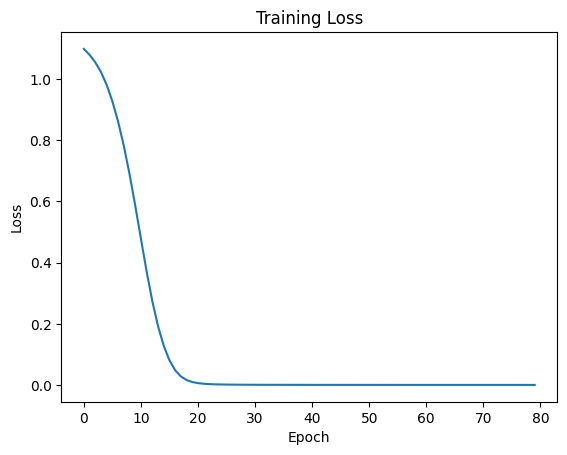

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

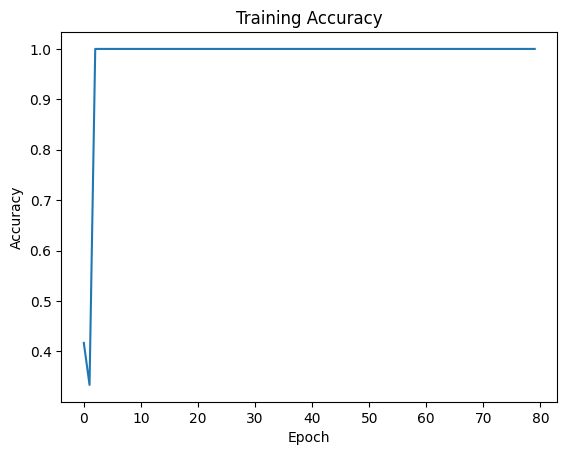

In [12]:
plt.plot(history.history['accuracy'])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy")
plt.show()

In [13]:
test_queries = np.array([
    "i want my money back for the charge",       # Expected: Billing (0)
    "the software keeps freezing on start",      # Expected: Tech Support (1)
    "i forgot my password need to reset it"      # Expected: Account (2)
])

# Vectorize test inputs
test_vec = vectorizer(test_queries).numpy()

# Get model predictions
predictions = model.predict(test_vec)
department_map = {0: "Billing", 1: "Tech Support", 2: "Account Management"}

for query, prob_dist in zip(test_queries, predictions):
    predicted_class = np.argmax(prob_dist)
    confidence = prob_dist[predicted_class] * 100
    print(f"Query: \"{query}\"")
    print(f"--> Route to: {department_map[predicted_class]} ({confidence:.2f}% confidence)\n")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 350ms/step
Query: "i want my money back for the charge"
--> Route to: Account Management (67.06% confidence)

Query: "the software keeps freezing on start"
--> Route to: Tech Support (99.52% confidence)

Query: "i forgot my password need to reset it"
--> Route to: Account Management (99.92% confidence)

